# 🎬 Regresión Lineal — ETL Películas OMDB
**Objetivo:** Predecir el `imdb_rating` de una película usando variables numéricas: `duracion`, `anio` y `recaudacion`.

| Variable | Descripción | Rol |
|---|---|---|
| `imdb_rating` | Puntuación IMDb (0–10) | 🎯 Variable objetivo (y) |
| `duracion` | Duración en minutos | Feature (x₁) |
| `anio` | Año de estreno | Feature (x₂) |
| `recaudacion` | Recaudación en USD | Feature (x₃) |

In [3]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


## 🗄️ Fase 2: Conexión a PostgreSQL y carga de datos

In [6]:
# ── CELDA 2: Carga de datos desde PostgreSQL ──────────────────
QUERY = """
SELECT
    p.titulo,
    r.anio,
    r.genero,
    r.director,
    r.imdb_rating,
    r.duracion,
    r.recaudacion,
    r.idioma,
    r.pais,
    r.fecha_extraccion
FROM registro_peliculas r
JOIN peliculas p ON r.pelicula_id = p.id
WHERE r.imdb_rating IS NOT NULL
  AND r.duracion    IS NOT NULL
  AND r.anio        IS NOT NULL
ORDER BY r.fecha_extraccion
"""

df_raw = pd.read_sql(QUERY, engine)

print(f"✅ Datos cargados desde PostgreSQL")
print(f"   Filas    : {df_raw.shape[0]:,}")
print(f"   Columnas : {df_raw.shape[1]}")
print(f"\n📋 Primeras filas:")
df_raw.head(10)

✅ Datos cargados desde PostgreSQL
   Filas    : 104
   Columnas : 10

📋 Primeras filas:


,titulo,anio,genero,director,imdb_rating,duracion,recaudacion,idioma,pais,fecha_extraccion
0,Inception,2010,"Action, Adventure, Sci-Fi",Christopher Nolan,8.8,148,292587330.0,"English, Japanese, French","United States, United Kingdom",2026-04-15 14:13:23.396596
1,Interstellar,2014,"Adventure, Drama, Sci-Fi",Christopher Nolan,8.7,169,203227580.0,English,"United States, United Kingdom, Canada",2026-04-15 14:13:24.858103
2,The Dark Knight,2008,"Action, Crime, Drama",Christopher Nolan,9.1,152,534987076.0,"English, Mandarin","United States, United Kingdom",2026-04-15 14:13:26.251749
3,Parasite,2019,"Drama, Thriller",Bong Joon Ho,8.5,132,53847897.0,"Korean, English",South Korea,2026-04-15 14:13:27.848542
4,Avatar,2009,"Action, Adventure, Fantasy",James Cameron,7.9,162,785221649.0,"English, Spanish","United States, United Kingdom",2026-04-15 14:13:30.383211
5,The Shawshank Redemption,1994,Drama,Frank Darabont,9.3,142,28767189.0,English,United States,2026-04-15 14:13:31.971855
6,The Godfather,1972,"Crime, Drama",Francis Ford Coppola,9.2,175,136381073.0,"English, Italian, Latin",United States,2026-04-15 14:13:33.442218
7,The Godfather Part II,1974,"Crime, Drama",Francis Ford Coppola,9.0,202,47834595.0,"English, Italian, Spanish, Latin, Sicilian",United States,2026-04-15 14:13:34.886828
8,Pulp Fiction,1994,"Crime, Drama",Quentin Tarantino,8.8,154,107928762.0,"English, Spanish, French",United States,2026-04-15 14:13:38.088050
9,Schindler's List,1993,"Biography, Drama, History",Steven Spielberg,9.0,195,96898818.0,"English, Hebrew, German, Polish, Latin",United States,2026-04-15 14:13:39.716335


In [7]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df_raw.info())
print("\n📊 Valores nulos por columna:")
print(df_raw.isnull().sum())
print(f"\n🎬 Total de películas: {df_raw['titulo'].nunique()}")

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   titulo            104 non-null    object        
 1   anio              104 non-null    int64         
 2   genero            104 non-null    object        
 3   director          104 non-null    object        
 4   imdb_rating       104 non-null    float64       
 5   duracion          104 non-null    int64         
 6   recaudacion       99 non-null     float64       
 7   idioma            104 non-null    object        
 8   pais              104 non-null    object        
 9   fecha_extraccion  104 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 8.3+ KB
None

📊 Valores nulos por columna:
titulo              0
anio                0
genero              0
director            0
imdb_rati

In [8]:
# ── CELDA 4: Preparar DataFrame limpio para el modelo ─────────
# Columnas numéricas clave
VARS_NUM = ['imdb_rating', 'duracion', 'anio', 'recaudacion']

# Trabajamos solo con filas que tengan imdb_rating, duracion y anio
# recaudacion puede tener muchos nulos (N/A en OMDB) → la tratamos aparte
df = df_raw.dropna(subset=['imdb_rating', 'duracion', 'anio']).copy()

# Log10 de recaudacion para normalizar escala (millones vs unidades)
df['recaudacion_log'] = np.where(
    df['recaudacion'].notna() & (df['recaudacion'] > 0),
    np.log10(df['recaudacion']),
    np.nan
)

print(f"✅ Dataset limpio para modelo: {df.shape[0]} filas")
print(f"   Películas con recaudacion: {df['recaudacion'].notna().sum()}")
print(f"   Películas sin recaudacion: {df['recaudacion'].isna().sum()}")
df[VARS_NUM].describe().round(2)

✅ Dataset limpio para modelo: 104 filas
   Películas con recaudacion: 99
   Películas sin recaudacion: 5


,imdb_rating,duracion,anio,recaudacion
count,104.00,104.00,104.00,9.900000e+01
mean,8.29,137.36,1992.55,1.246517e+08
std,0.44,33.74,18.00,1.546400e+08
min,6.70,30.00,1942.00,6.672800e+04
25%,8.10,114.75,1981.75,3.069062e+07
50%,8.30,132.00,1996.50,7.428362e+07
75%,8.50,158.25,2006.00,1.585429e+08
max,9.30,229.00,2019.00,8.583730e+08


## 🔍 Fase 3: EDA — Análisis Exploratorio de Datos

In [9]:
# ── CELDA 5: Estadísticas descriptivas ───────────────────────
desc = df[VARS_NUM].describe().round(2)
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       imdb_rating  duracion     anio   recaudacion
count       104.00    104.00   104.00  9.900000e+01
mean          8.29    137.36  1992.55  1.246517e+08
std           0.44     33.74    18.00  1.546400e+08
min           6.70     30.00  1942.00  6.672800e+04
25%           8.10    114.75  1981.75  3.069062e+07
50%           8.30    132.00  1996.50  7.428362e+07
75%           8.50    158.25  2006.00  1.585429e+08
max           9.30    229.00  2019.00  8.583730e+08


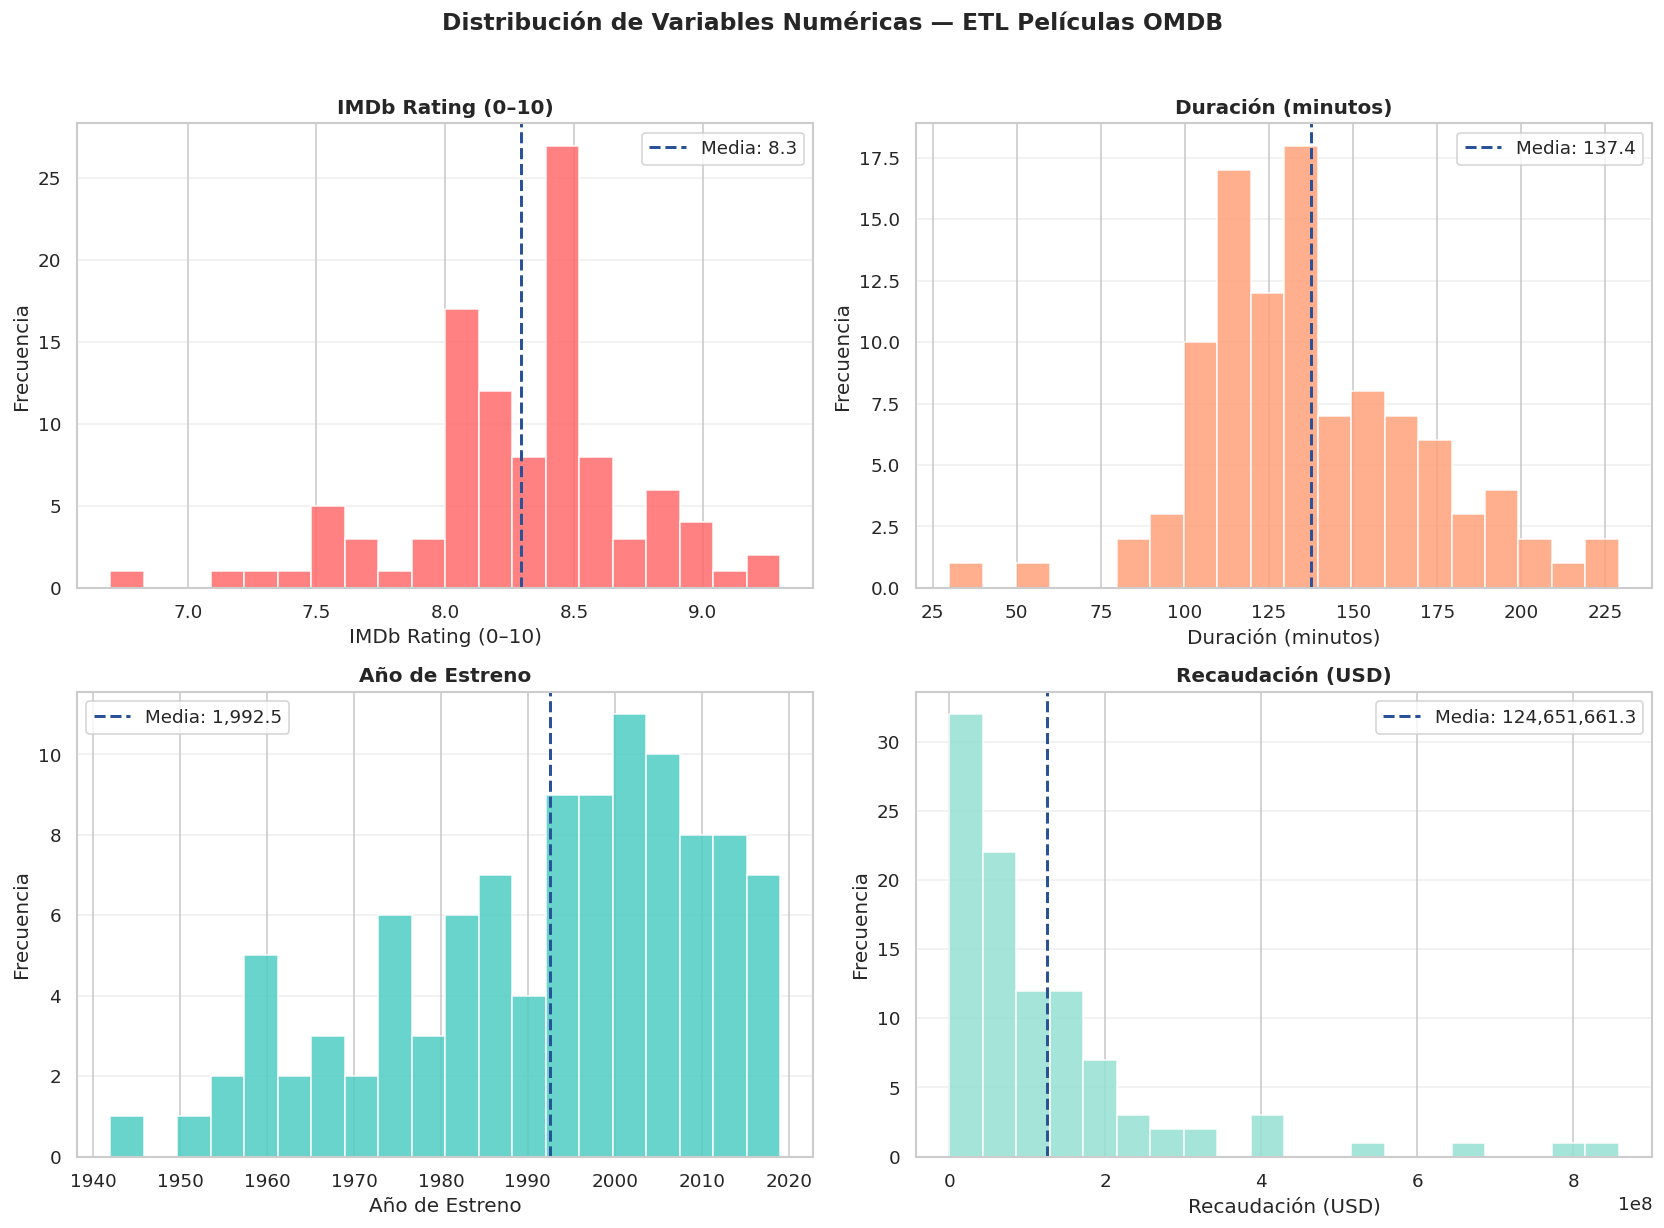

✅ Guardado en data/graficas/eda_distribuciones.png


In [10]:
# ── CELDA 6: Histogramas de distribución ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Numéricas — ETL Películas OMDB',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'imdb_rating':  ('IMDb Rating (0–10)',       '#ff6b6b'),
    'duracion':     ('Duración (minutos)',        '#ffa07a'),
    'anio':         ('Año de Estreno',            '#4ecdc4'),
    'recaudacion':  ('Recaudación (USD)',          '#95e1d3'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    data_col = df[col].dropna()
    ax.hist(data_col, bins=20, color=color, edgecolor='white', alpha=0.85)
    media = data_col.mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:,.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado en data/graficas/eda_distribuciones.png")

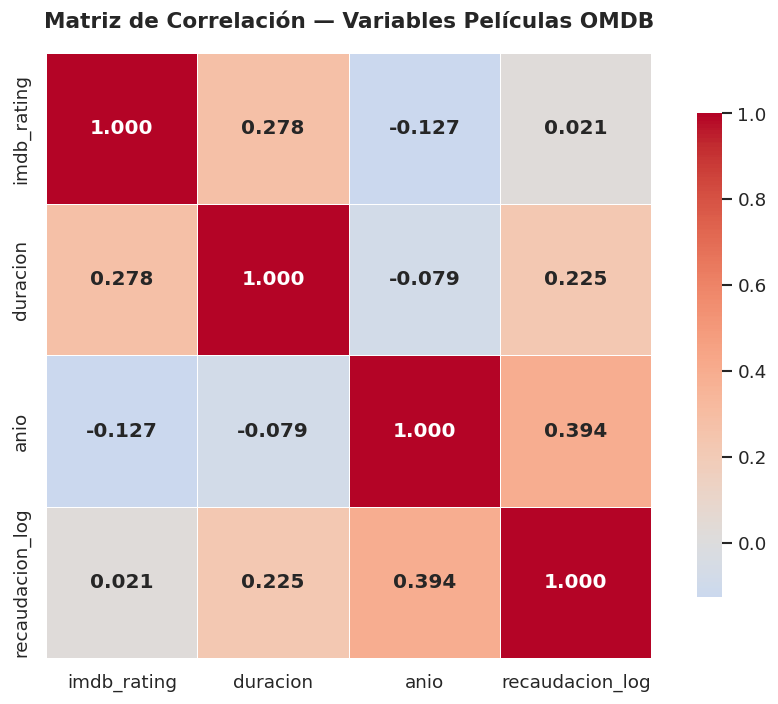


📊 Correlación con imdb_rating (ordenada):
duracion           0.2784
recaudacion_log    0.0215
anio              -0.1273
Name: imdb_rating, dtype: float64


In [11]:
# ── CELDA 7: Matriz de correlación ───────────────────────────
vars_corr = ['imdb_rating', 'duracion', 'anio', 'recaudacion_log']
corr = df[vars_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables Películas OMDB',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Correlación con imdb_rating (ordenada):")
print(corr['imdb_rating'].drop('imdb_rating').sort_values(ascending=False).round(4))

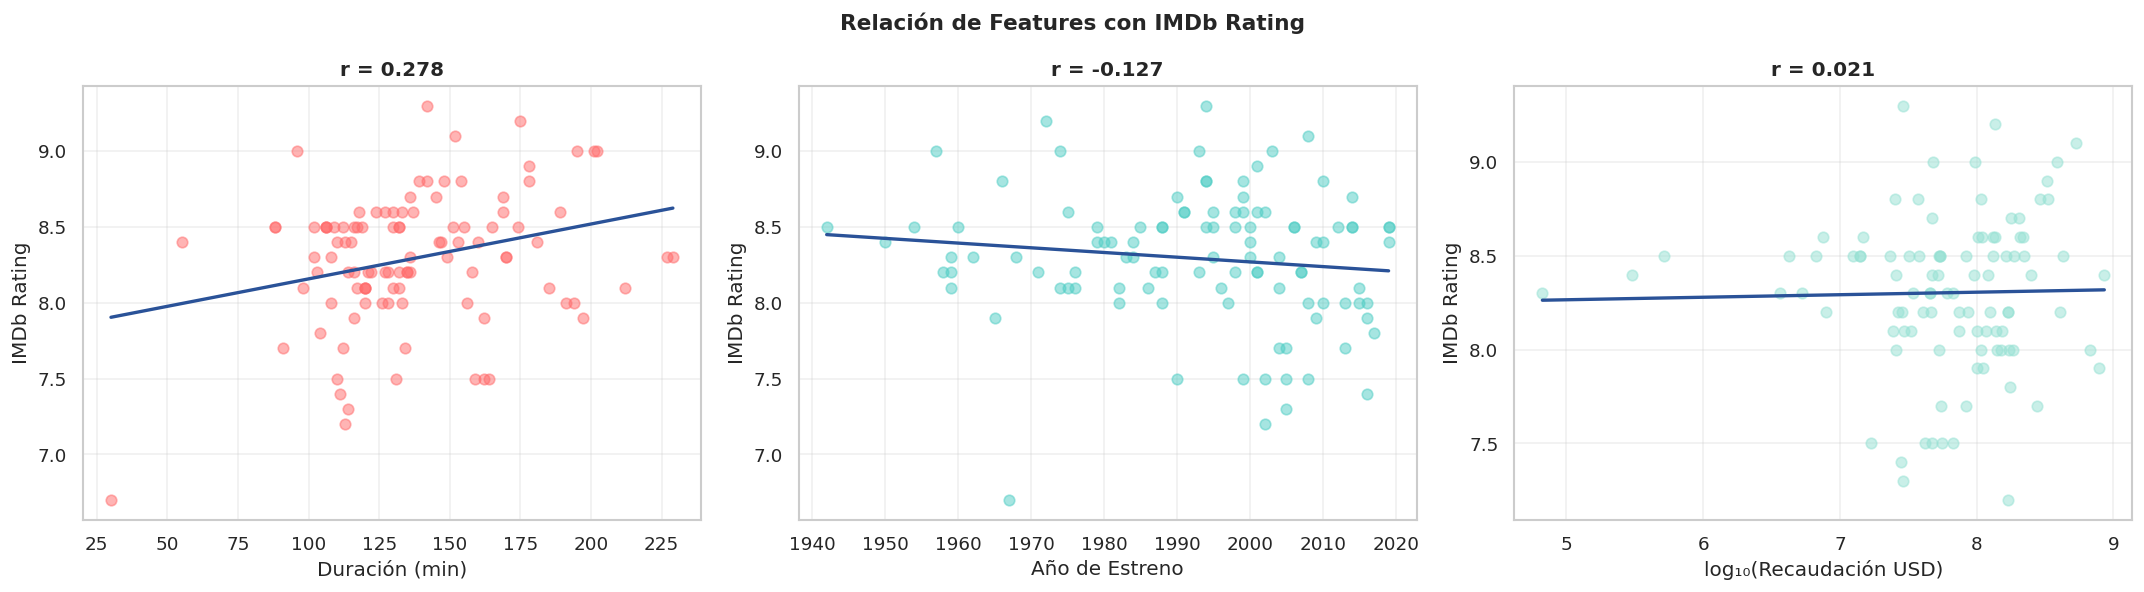

In [11]:
# ── CELDA 8: Scatter plots bivariados ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con IMDb Rating',
             fontsize=13, fontweight='bold')

pares = [
    ('duracion',        'Duración (min)',           '#ff6b6b'),
    ('anio',            'Año de Estreno',            '#4ecdc4'),
    ('recaudacion_log', 'log₁₀(Recaudación USD)',    '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    data_feat = df[[feature, 'imdb_rating']].dropna()
    ax.scatter(data_feat[feature], data_feat['imdb_rating'],
               alpha=0.5, s=40, color=color)
    z = np.polyfit(data_feat[feature], data_feat['imdb_rating'], 1)
    p = np.poly1d(z)
    xp = np.linspace(data_feat[feature].min(), data_feat[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = data_feat[[feature, 'imdb_rating']].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('IMDb Rating')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

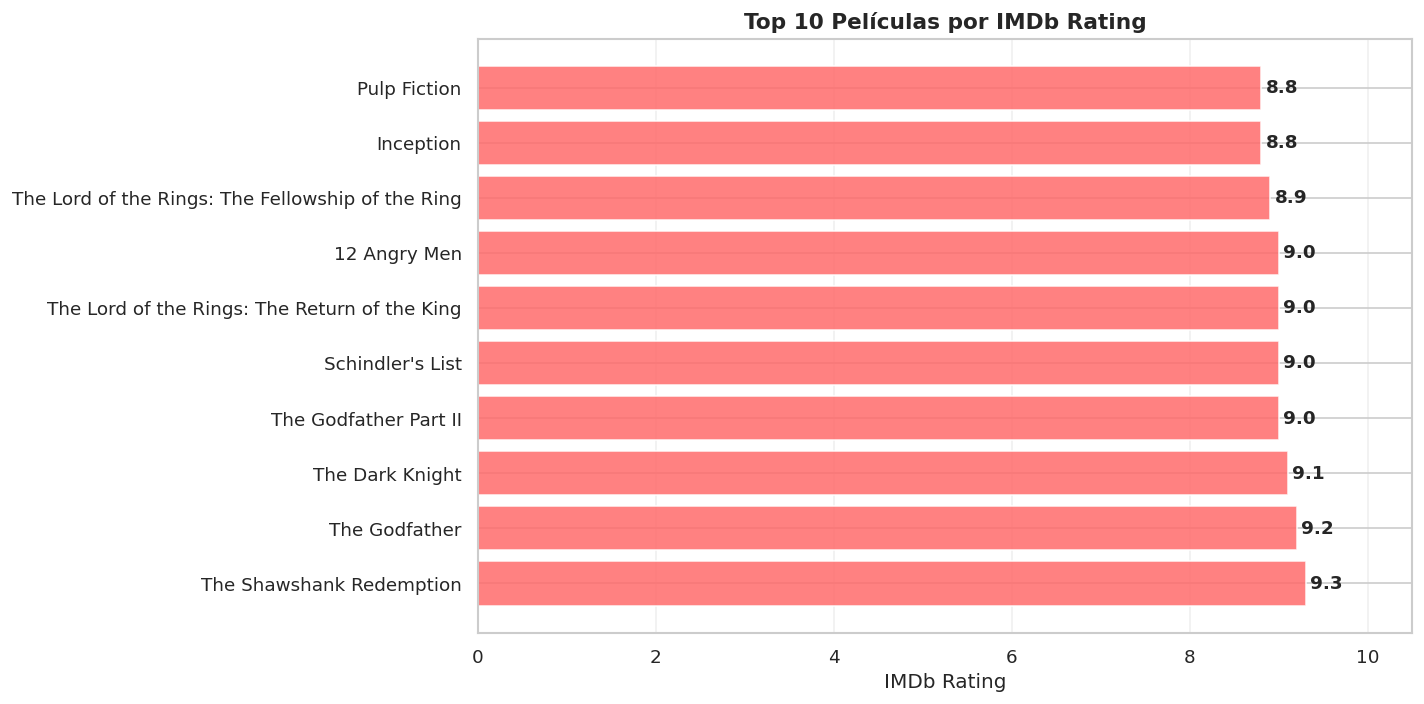

In [12]:
# ── CELDA 9: Top 10 películas por IMDb Rating ─────────────────
fig, ax = plt.subplots(figsize=(12, 6))
top10 = df.nlargest(10, 'imdb_rating')[['titulo', 'imdb_rating', 'anio']].reset_index(drop=True)

bars = ax.barh(top10['titulo'], top10['imdb_rating'],
               color='#ff6b6b', edgecolor='white', alpha=0.85)
ax.set_xlabel('IMDb Rating', fontsize=12)
ax.set_title('Top 10 Películas por IMDb Rating', fontsize=13, fontweight='bold')
ax.set_xlim(0, 10.5)
for bar, val in zip(bars, top10['imdb_rating']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/top10_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## 📐 Fase 4: Regresión Lineal Simple
**Objetivo:** Predecir `imdb_rating` usando únicamente `duracion` como variable independiente.

```
ŷ = β₀ + β₁·duracion + ε
```

In [13]:
# ── CELDA 10: Split Train / Test ─────────────────────────────
df_simple = df[['duracion', 'imdb_rating']].dropna()

X_simple = df_simple[['duracion']].values
y        = df_simple['imdb_rating'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 83 muestras (80%)
Test : 21 muestras  (20%)


In [14]:
# ── CELDA 11: Entrenamiento con scikit-learn ──────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.6f}")
print(f"\nEcuación : imdb_rating = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.4f} × duracion")

Intercepto  β₀ : 7.8160
Coeficiente β₁ : 0.003511

Ecuación : imdb_rating = 7.816 + 0.0035 × duracion


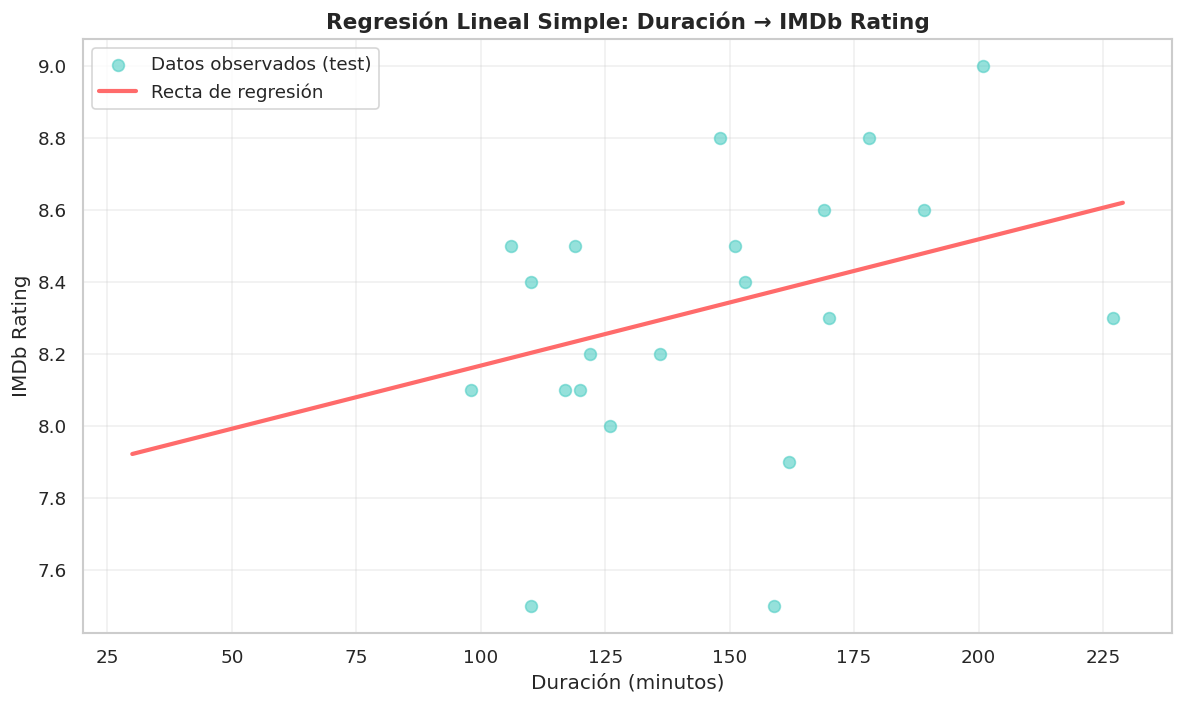

In [15]:
# ── CELDA 12: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.6, s=50,
           color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Duración (minutos)', fontsize=12)
ax.set_ylabel('IMDb Rating', fontsize=12)
ax.set_title('Regresión Lineal Simple: Duración → IMDb Rating',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── CELDA 13: Métricas del modelo simple ─────────────────────
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.1354  (13.54%)
  MSE  (error cuadrático med)  : 0.1227
  RMSE (raíz del MSE)          : 0.3503
  MAE  (error absoluto medio)  : 0.2760


In [17]:
# ── CELDA 14: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df_simple['duracion'])
modelo_ols_simple = sm.OLS(df_simple['imdb_rating'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     8.568
Date:                Wed, 15 Apr 2026   Prob (F-statistic):            0.00422
Time:                        14:30:21   Log-Likelihood:                -57.159
No. Observations:                 104   AIC:                             118.3
Df Residuals:                     102   BIC:                             123.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.7953      0.175     44.593      0.0

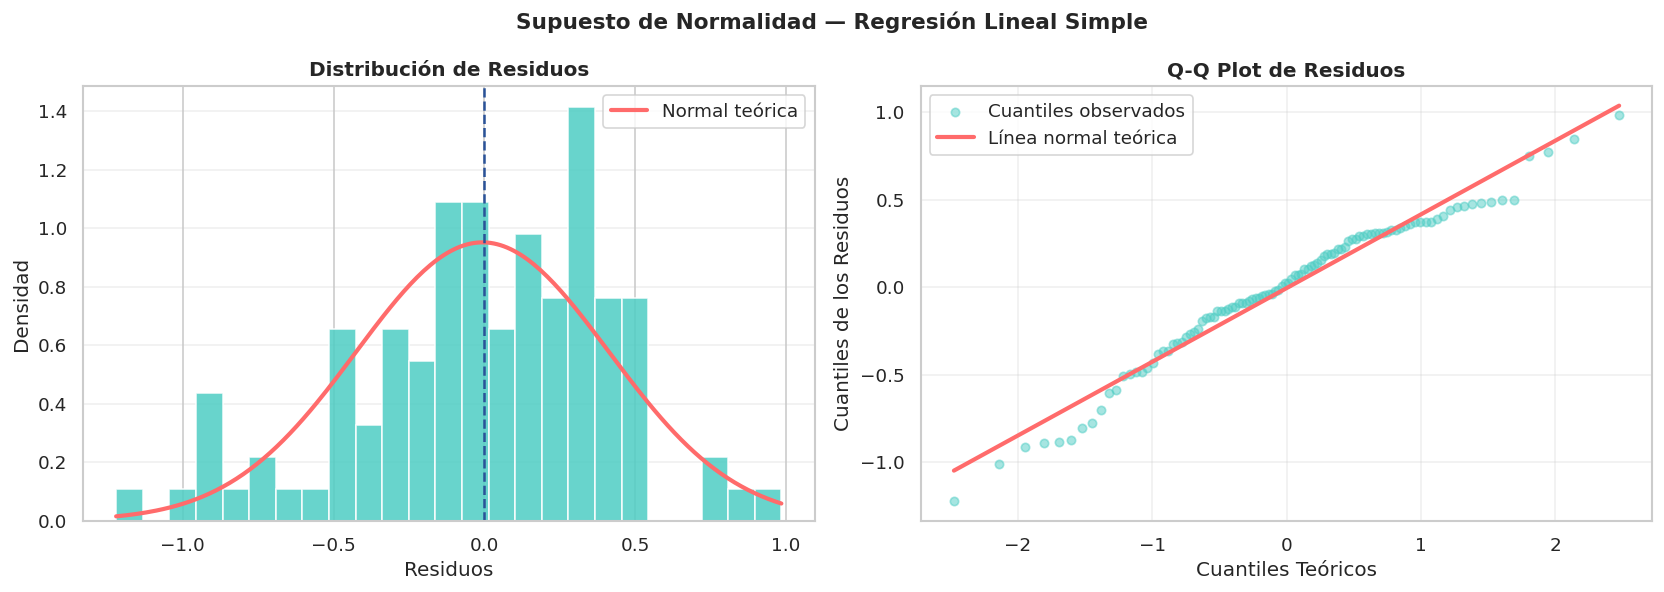


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9717
   p-value       : 0.024973
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)


In [18]:
# ── CELDA 15: Normalidad de residuos (modelo simple) ─────────
y_pred_all = modelo_simple.predict(df_simple[['duracion']].values)
residuos   = df_simple['imdb_rating'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(residuos, bins=25, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.5, s=25, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png', dpi=150, bbox_inches='tight')
plt.show()

# Test Shapiro-Wilk
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")

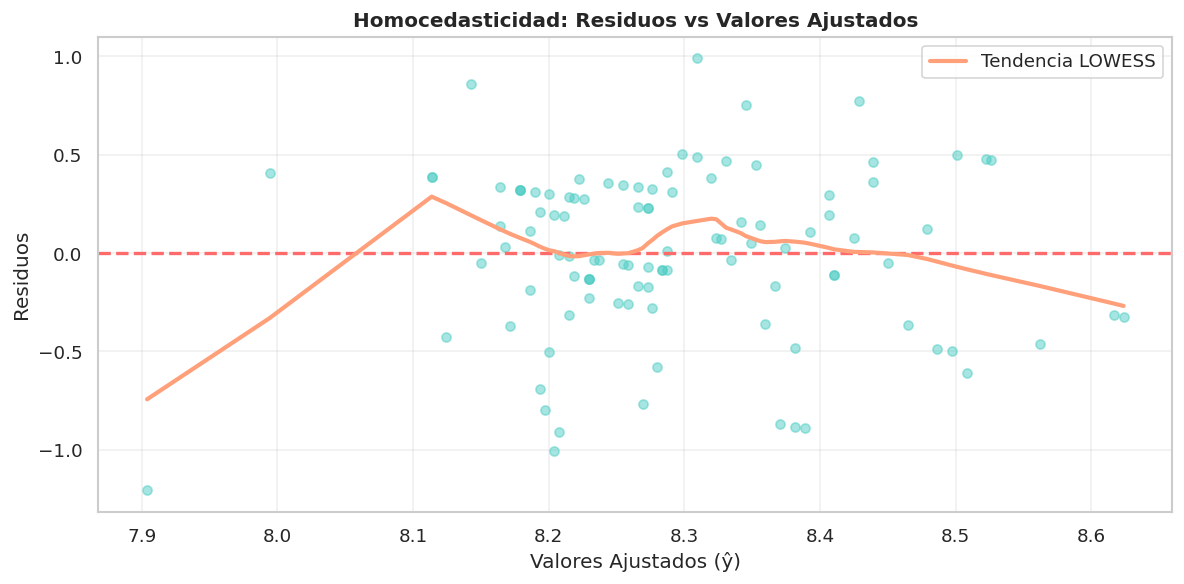


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 1.0874
   p-value        : 0.297037
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [19]:
# ── CELDA 16: Homocedasticidad (modelo simple) ───────────────
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.5, s=30, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.4)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png', dpi=150, bbox_inches='tight')
plt.show()

# Test Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(residuos_ols, modelo_ols_simple.model.exog)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")
if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

## 📐 Fase 5: Regresión Lineal Múltiple
**Objetivo:** Predecir `imdb_rating` usando `duracion`, `anio` y `recaudacion_log`.

```
ŷ = β₀ + β₁·duracion + β₂·anio + β₃·recaudacion_log + ε
```

In [14]:
# ── CELDA 17: Preparación — modelo múltiple ───────────────────
# Solo filas con las 3 features disponibles
FEATURES = ['duracion', 'anio', 'recaudacion_log']

df_multi = df[FEATURES + ['imdb_rating']].dropna()
print(f"📊 Filas disponibles para modelo múltiple: {len(df_multi)}")
print(f"   (Se descartan películas sin recaudacion en OMDB)")

X_multi = df_multi[FEATURES].values
y_m     = df_multi['imdb_rating'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_m, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)
y_pred_multi = modelo_multi.predict(X_test_m)

print(f"\nIntercepto  β₀              : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>18} : {coef:.6f}")

📊 Filas disponibles para modelo múltiple: 99
   (Se descartan películas sin recaudacion en OMDB)

Intercepto  β₀              : 16.9088
Coeficiente           duracion : 0.002733
Coeficiente               anio : -0.004598
Coeficiente    recaudacion_log : 0.021798


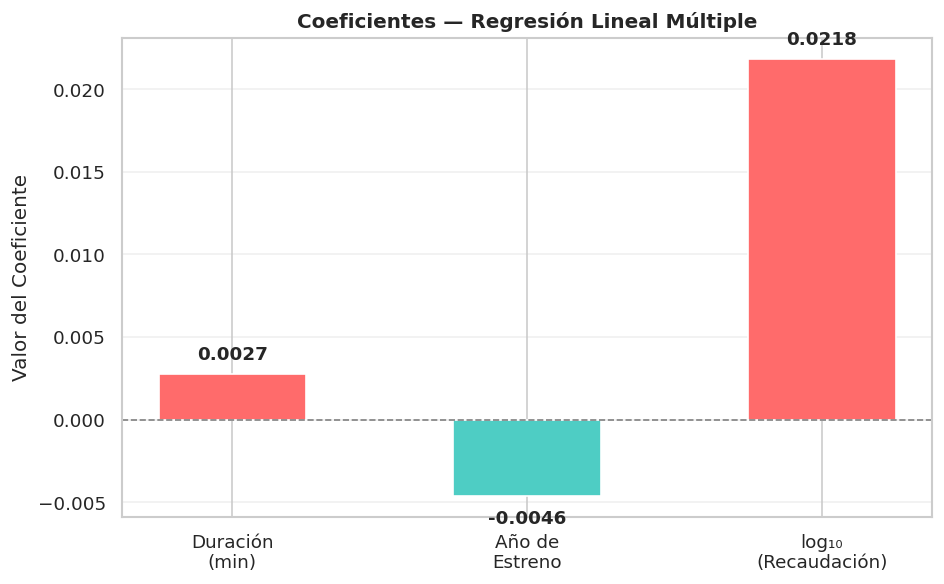

In [15]:
# ── CELDA 18: Gráfica de coeficientes ────────────────────────
labels_feat = ['Duración\n(min)', 'Año de\nEstreno', 'log₁₀\n(Recaudación)']
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels_feat, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = max(abs(modelo_multi.coef_)) * 0.03
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (offset if coef >= 0 else -offset * 3),
            f'{coef:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── CELDA 19: Métricas — modelo múltiple ─────────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.0331  (3.31%)
  MSE  (error cuadrático med)  : 0.0943
  RMSE (raíz del MSE)          : 0.3070
  MAE  (error absoluto medio)  : 0.2512


In [22]:
# ── CELDA 20: OLS statsmodels — modelo múltiple ──────────────
X_ols_m = sm.add_constant(df_multi[FEATURES])
modelo_ols_multi = sm.OLS(df_multi['imdb_rating'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:            imdb_rating   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     2.749
Date:                Wed, 15 Apr 2026   Prob (F-statistic):             0.0471
Time:                        14:31:32   Log-Likelihood:                -48.286
No. Observations:                  99   AIC:                             104.6
Df Residuals:                      95   BIC:                             115.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              15.7770      5.081     

In [23]:
# ── CELDA 21: VIF — Factor de Inflación de la Varianza ───────
X_vif = df_multi[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data["VIF"] = vif_data["VIF"].round(3)
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️  Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
       Variable     VIF            Criterio
       duracion  22.359 ❌ Severa (VIF ≥ 10)
           anio 155.136 ❌ Severa (VIF ≥ 10)
recaudacion_log 161.376 ❌ Severa (VIF ≥ 10)


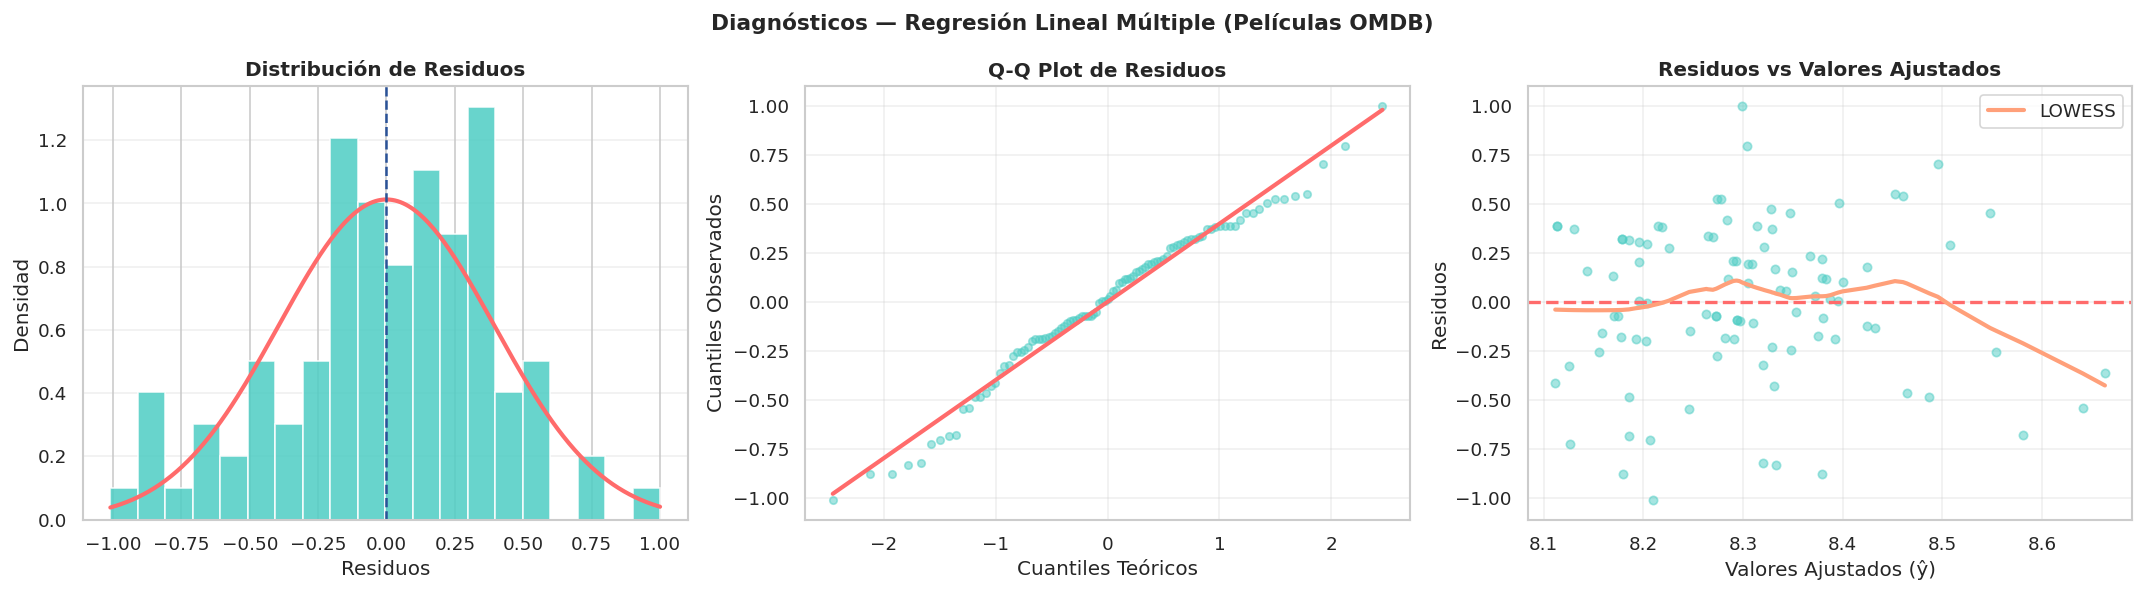


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.143405 → ✅ No se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.181864 → ✅ Homocedasticidad OK


In [24]:
# ── CELDA 22: Diagnósticos completos — modelo múltiple ───────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Películas OMDB)',
             fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(residuos_m, bins=20, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.5, s=20, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.5, s=25, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.4)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png', dpi=150, bbox_inches='tight')
plt.show()

# Tests
stat_sw_m, p_sw_m = stats.shapiro(residuos_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

print(f"\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️  Se rechaza normalidad'}")

print(f"\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️  Heterocedasticidad detectada'}")

## 📊 Fase 6: Comparación de Modelos

In [25]:
# ── CELDA 23: Tabla comparativa ──────────────────────────────
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['duracion',
                  'duracion + anio + log(recaudacion)'],
    'n_train'  : [X_train.shape[0], X_train_m.shape[0]],
    'R²'       : [round(r2,   4), round(r2_m,   4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj,  4)],
    'RMSE'     : [round(rmse,  4), round(rmse_m,  4)],
    'MAE'      : [round(mae,   4), round(mae_m,   4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic,  2)],
})

print("=" * 80)
print("              COMPARACIÓN DE MODELOS — ETL PELÍCULAS OMDB")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)
print("\n📌 AIC más bajo → mejor equilibrio entre ajuste y parsimonia")
print("📌 RMSE en puntos IMDb (escala 0–10)")

              COMPARACIÓN DE MODELOS — ETL PELÍCULAS OMDB
            Modelo                          Variables  n_train     R²  R² Aj.   RMSE    MAE    AIC
  Regresión Simple                           duracion       83 0.1354  0.0684 0.3503 0.2760 118.32
Regresión Múltiple duracion + anio + log(recaudacion)       79 0.0331  0.0508 0.3070 0.2512 104.57

📌 AIC más bajo → mejor equilibrio entre ajuste y parsimonia
📌 RMSE en puntos IMDb (escala 0–10)


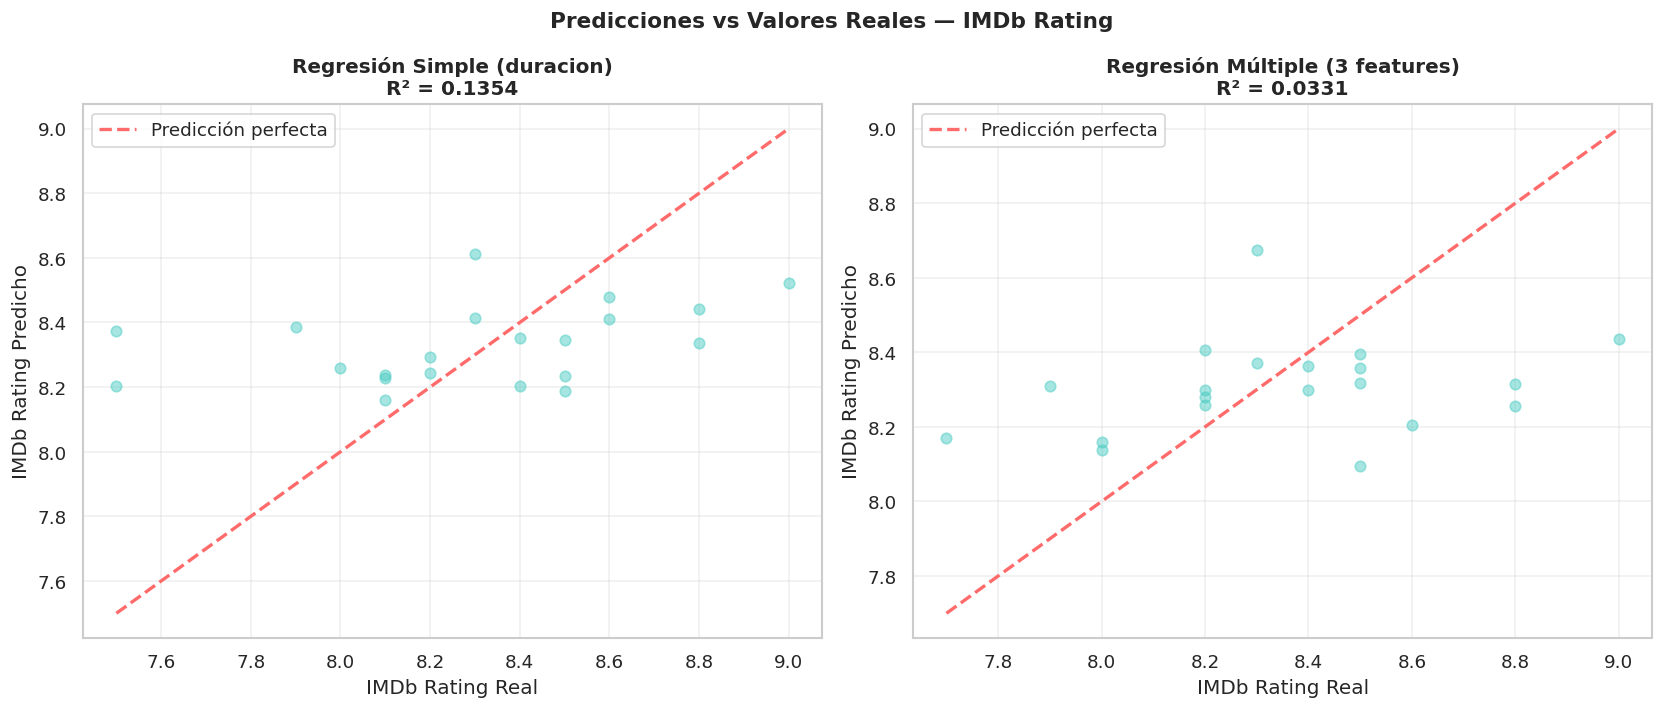

In [26]:
# ── CELDA 24: Predicciones vs Reales — ambos modelos ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales — IMDb Rating',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple (duracion)'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple (3 features)'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.5, s=40, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo}\nR² = {r2_val:.4f}', fontweight='bold')
    ax.set_xlabel('IMDb Rating Real')
    ax.set_ylabel('IMDb Rating Predicho')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Predictor interactivo
Ingresa los datos de una película nueva para predecir su IMDb Rating.

In [27]:
# ── CELDA 25: Predictor con el modelo múltiple ────────────────
# Cambia estos valores para predecir cualquier película
nueva_pelicula = {
    'titulo':      'Mi Película de Prueba',
    'duracion':    142,          # minutos
    'anio':        2023,         # año de estreno
    'recaudacion': 500_000_000   # USD (0 si no se conoce)
}

rec_log = np.log10(nueva_pelicula['recaudacion']) if nueva_pelicula['recaudacion'] > 0 else 0
X_nueva = np.array([[nueva_pelicula['duracion'],
                     nueva_pelicula['anio'],
                     rec_log]])

pred = modelo_multi.predict(X_nueva)[0]
pred_clamp = np.clip(pred, 1.0, 10.0)  # IMDb va de 1 a 10

print(f"🎬 Película      : {nueva_pelicula['titulo']}")
print(f"   Duración      : {nueva_pelicula['duracion']} min")
print(f"   Año           : {nueva_pelicula['anio']}")
print(f"   Recaudación   : ${nueva_pelicula['recaudacion']:,.0f}")
print(f"\n⭐ IMDb Rating predicho : {pred_clamp:.2f} / 10")

🎬 Película      : Mi Película de Prueba
   Duración      : 142 min
   Año           : 2023
   Recaudación   : $500,000,000

⭐ IMDb Rating predicho : 8.19 / 10
